# Model Training

Notebook version that reuses the training utilities from `clearsky_lstm.py`.


In [19]:
from types import SimpleNamespace
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

from data import NEXRADDataset
from clearsky_lstm import (
    ConvLSTMForecaster,
    SmaAtUNet,
    device,
    train_one_epoch,
    evaluate,
)


In [20]:
RAW_DATA_PATH = "data/raw"
CACHE_DATA_PATH = "data/cache"
STATION = "KAMX"
VAL_FRAC = 0.1
TEST_FRAC = 0.1
SEED = 13
BATCH_SIZE = 8
NUM_WORKERS = 4
MODEL = "smaat_unet"
T_IN = 6
T_OUT = 6
HIDDEN_CHANNELS = [64, 64, 64]
NUM_LAYERS = 3
TEACHER_FORCING = 0.0
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.0
EPOCHS = 20
SAVE_SAMPLES = True
SAMPLE_DIR = "samples"
MODEL_OUT = "checkpoints/final_model.pt"

args = SimpleNamespace(
    model=MODEL,
    stations=[STATION],
    t_in=T_IN,
    t_out=T_OUT,
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    hidden_ch=HIDDEN_CHANNELS,
    num_layers=NUM_LAYERS,
    teacher_forcing=TEACHER_FORCING,
    save_samples=SAVE_SAMPLES,
    sample_dir=SAMPLE_DIR,
    model_out=MODEL_OUT,
    seed=SEED,
)

print(f"Using device: {device}")
print(args)


Using device: cuda
namespace(model='smaat_unet', stations=['KAMX'], t_in=6, t_out=6, val_frac=0.1, test_frac=0.1, batch_size=8, num_workers=4, epochs=20, lr=0.0001, weight_decay=0.0, hidden_ch=[64, 64, 64], num_layers=3, teacher_forcing=0.0, save_samples=True, sample_dir='samples', model_out='checkpoints/final_model.pt', seed=13)


In [21]:
print("Building dataset...")
ds = NEXRADDataset(
    raw_root=RAW_DATA_PATH,
    stations=args.stations,
    t_in=args.t_in,
    t_out=args.t_out,
    cache_root=CACHE_DATA_PATH,
)

n = len(ds)
n_val = int(args.val_frac * n)
n_test = int(args.test_frac * n)
n_train = n - n_val - n_test
print(f"Dataset size: {n}")
print(f"Train/val/test split: {n_train}/{n_val}/{n_test}")

torch.manual_seed(args.seed)
train_ds, val_ds, test_ds = random_split(ds, [n_train, n_val, n_test])

train_loader = DataLoader(
    train_ds,
    batch_size=args.batch_size,
    shuffle=True,
    num_workers=args.num_workers,
)
val_loader = DataLoader(
    val_ds,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
)
test_loader = DataLoader(
    test_ds,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
)

print("Dataloaders ready.")


Building dataset...
Dataset size: 7945
Train/val/test split: 6357/794/794
Dataloaders ready.


In [22]:
if args.model == "smaat_unet":
    model = SmaAtUNet(in_channels=args.t_in, out_channels=args.t_out)
else:
    model = ConvLSTMForecaster(hidden_ch=args.hidden_ch, num_layers=args.num_layers)

model = model.to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=args.lr,
    weight_decay=args.weight_decay,
)
criterion = torch.nn.L1Loss()

print(model.__class__.__name__)
print("Model built and optimizer initialized.")


SmaAtUNet
Model built and optimizer initialized.


In [23]:
history = {"train_loss": [], "val_loss": []}

print("Beginning training...")
for epoch in range(args.epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, args)
    val_loss = evaluate(model, val_loader, criterion, device, args, epoch)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch + 1}/{args.epochs} | train: {train_loss:.3f} | val: {val_loss:.3f}")


Beginning training...
Input Range: 0.0000 to 0.8971
Pred Range: -3.9111 to 2.8596
Target Range: 0.0000 to 0.8873
Epoch 1/20 | train: 0.096 | val: 0.082
Input Range: 0.0000 to 0.9020
Pred Range: -0.2222 to 1.0945
Target Range: 0.0000 to 0.8676
Epoch 2/20 | train: 0.082 | val: 0.080
Input Range: 0.0000 to 0.9020
Pred Range: -0.1621 to 1.3987
Target Range: 0.0000 to 0.8971
Epoch 3/20 | train: 0.080 | val: 0.080
Input Range: 0.0000 to 0.8676
Pred Range: -0.1796 to 0.8180
Target Range: 0.0000 to 0.8676
Epoch 4/20 | train: 0.079 | val: 0.078
Input Range: 0.0000 to 0.8824
Pred Range: -0.1255 to 0.9375
Target Range: 0.0000 to 0.8922
Epoch 5/20 | train: 0.078 | val: 0.078
Input Range: 0.0000 to 0.8971
Pred Range: -0.0773 to 0.9999
Target Range: 0.0000 to 0.8824
Epoch 6/20 | train: 0.077 | val: 0.077
Input Range: 0.0000 to 0.8922
Pred Range: -0.3283 to 1.0351
Target Range: 0.0000 to 0.9167
Epoch 7/20 | train: 0.077 | val: 0.077
Input Range: 0.0000 to 0.9951
Pred Range: -0.0804 to 1.0962
Target R

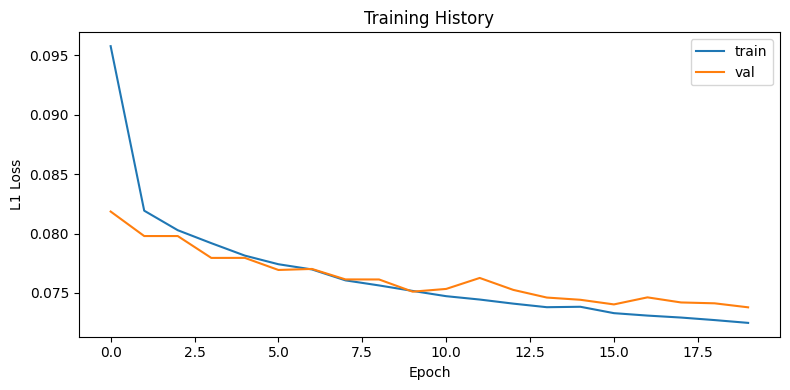

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training History")
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 1616166


In [38]:
from loss_functions import ReflectivityBMAELoss, ReflectivityBMSELoss

bmsa_loss_args = SimpleNamespace(
    model=MODEL,
    stations=[STATION],
    t_in=T_IN,
    t_out=T_OUT,
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    hidden_ch=HIDDEN_CHANNELS,
    num_layers=NUM_LAYERS,
    teacher_forcing=TEACHER_FORCING,
    save_samples=SAVE_SAMPLES,
    sample_dir="samples/bmsa_loss_smaat_unet",
    model_out=MODEL_OUT,
    seed=SEED,
)

bmsa_loss_model = SmaAtUNet(in_channels=bmsa_loss_args.t_in, out_channels=bmsa_loss_args.t_out)
bmsa_loss_model = bmsa_loss_model.to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=bmsa_loss_args.lr,
    weight_decay=bmsa_loss_args.weight_decay,
)
bmsa_loss_criterion = ReflectivityBMAELoss()
print(bmsa_loss_model.__class__.__name__)
print("Model built and optimizer initialized.")


SmaAtUNet
Model built and optimizer initialized.


In [39]:
bmsa_loss_history = {"train_loss": [], "val_loss": []}

print("Beginning training...")
for epoch in range(bmsa_loss_args.epochs):
    train_loss = train_one_epoch(bmsa_loss_model, train_loader, optimizer, bmsa_loss_criterion, device, bmsa_loss_args)
    val_loss = evaluate(bmsa_loss_model, val_loader, bmsa_loss_criterion, device, bmsa_loss_args, epoch)

    bmsa_loss_history["train_loss"].append(train_loss)
    bmsa_loss_history["val_loss"].append(val_loss)

    print(f"Epoch {epoch + 1}/{bmsa_loss_args.epochs} | train: {train_loss:.3f} | val: {val_loss:.3f}")


Beginning training...
Input Range: 0.0000 to 0.9020
Pred Range: -4.8205 to 4.1130
Target Range: 0.0000 to 0.8824
Epoch 1/20 | train: 33507.468 | val: 34987.499
Input Range: 0.0000 to 0.8824
Pred Range: -6.2222 to 5.7193
Target Range: 0.0000 to 0.9167
Epoch 2/20 | train: 33513.517 | val: 33620.977
Input Range: 0.0000 to 0.9020
Pred Range: -6.6360 to 3.4296
Target Range: 0.0000 to 0.8627
Epoch 3/20 | train: 33516.621 | val: 33697.570
Input Range: 0.0000 to 0.8873
Pred Range: -5.8951 to 3.7402
Target Range: 0.0000 to 0.9265
Epoch 4/20 | train: 33517.544 | val: 33928.279
Input Range: 0.0000 to 0.8971
Pred Range: -6.1117 to 4.5467
Target Range: 0.0000 to 0.9118
Epoch 5/20 | train: 33518.759 | val: 34462.112
Input Range: 0.0000 to 0.9216
Pred Range: -5.2854 to 4.1878
Target Range: 0.0000 to 0.9510
Epoch 6/20 | train: 33520.207 | val: 35147.464
Input Range: 0.0000 to 0.9657
Pred Range: -5.9854 to 3.4952
Target Range: 0.0000 to 0.9069
Epoch 7/20 | train: 33527.549 | val: 32863.980
Input Range:

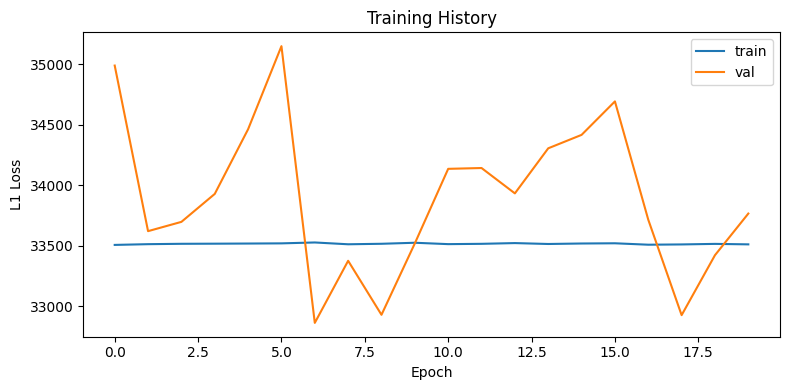

In [40]:
plt.figure(figsize=(8, 4))
plt.plot(bmsa_loss_history["train_loss"], label="train")
plt.plot(bmsa_loss_history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training History")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# print("Evaluating model...")
# test_loss = evaluate(bmsa_loss_model, test_loader, criterion, device, args)
# print(f"Final loss on test set: {test_loss:.3f}")

In [41]:
# print("Evaluating model...")
# test_loss = evaluate(bmsa_loss_model, test_loader, criterion, device, args)
# print(f"Final loss on test set: {test_loss:.3f}")

# # model_dir = os.path.dirname(args.model_out)
# # if model_dir:
# #     os.makedirs(model_dir, exist_ok=True)
# # torch.save(model.state_dict(), args.model_out)
# # print(f"Saved final model parameters to {args.model_out}")


Evaluating model...
Final loss on test set: 0.362
